# 6 · Métodos modernos, leaderboard final y conclusiones

**Última pregunta de exhaustividad:** ¿un método moderno de deep anomaly detection
supera lo nuestro? Benchmark vía `deepod`: **DeepSVDD** (one-class), **ICL**
(contrastive), **NeuTraL** (transformaciones aprendidas).

> **Protocolo justo:** mismas 300 épocas que nuestros modelos, capacidad equivalente
> (hidden 64,32 + rep_dim 16) y multi-seed — no los defaults de la librería. GOAD quedó
> afuera por costo prohibitivo (256 transformaciones por época).

In [1]:
import os, explib
os.chdir(explib.ROOT)          # rutas relativas (data/, configs/, runs/) funcionan
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
plt.rcParams['figure.dpi'] = 110

In [2]:
explib.show(explib.tbl_modern())

,modelo,soja_pr,maiz_pr,nota
0,VAE seed-ensemble (nuestro),0.592,0.508,mejor del proyecto
1,IForest (baseline),0.511,0.492,—
2,DeepSVDD,0.467,0.389,deep one-class; el mejor de los modernos
3,ICL,0.344,0.389,internal contrastive learning
4,NeuTraL,0.239,0.239,transformaciones; ~azar
5,GOAD,NaN,NaN,costo prohibitivo (256 transf./época)


In [3]:
explib.show(explib.compare_table([
    ("deepod_deepsvdd","DeepSVDD"), ("deepod_icl","ICL"), ("deepod_neutral","NeuTraL"),
    ("iforest_v2_mf03_n200","IForest"), ("vae_seedens_v1","VAE seed-ens")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,DeepSVDD,0.467±0.058,0.733±0.017,0.510±0.076,0.498±0.040,0.191±0.044
1,ICL,0.344±0.053,0.577±0.010,0.394±0.023,0.359±0.028,0.144±0.069
2,NeuTraL,0.239±0.033,0.466±0.103,0.041±0.030,0.171±0.051,0.026±0.011
3,IForest,0.511±0.031,0.688±0.030,0.390±0.034,0.470±0.035,0.266±0.023
4,VAE seed-ens,0.592±0.010,0.738±0.005,0.432±0.003,0.558±0.013,0.297±0.002


**Ninguno supera al VAE — ni siquiera al IForest.** Lectura honesta: esto no nos
hace estado del arte del campo; dice que en *este* dataset, con presupuesto parejo, no
despegan. Es coherente con el techo estructural (nb. 4): no hay señal extra que un método
más sofisticado pueda exprimir.

## 6.1 · Leaderboard final (media ± desvío, test)

In [4]:
explib.show(explib.tbl_leaderboard())

,model,desc,soja_pr,soja_std,maiz_pr,maiz_std
0,vae_seedens_v1 ⭐,VAE seed-ensemble (lat16),0.592,0.010,0.508,0.005
1,vae_seedens_deep,VAE seed-ensemble (deep),0.585,0.007,0.500,0.003
2,vae_v4 (single),VAE recon_prob single,0.559,0.035,0.479,0.070
3,vae_v15 (single),VAE recon_prob deep single,0.553,0.036,0.489,0.060
4,iforest_v2,Isolation Forest (mf=0.3),0.511,0.031,0.492,0.030


/Users/joaquin/Documents/facultad /ml/tp final/Trabajo_final_ML/componente_a/experiments/explib.py:482: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  ax.legend(); ax.grid(axis="x", alpha=0.3); fig.tight_layout(); return fig
/Users/joaquin/Documents/facultad /ml/tp final/Trabajo_final_ML/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


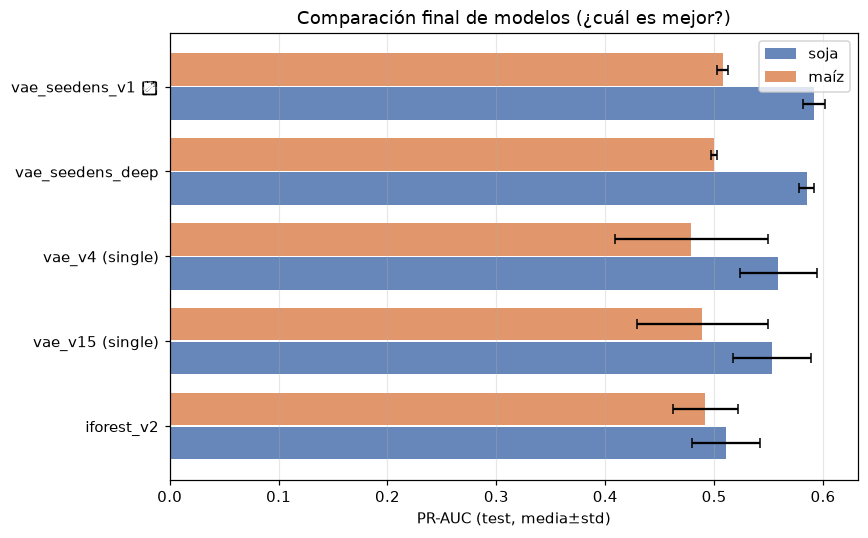

In [5]:
explib.plot_leaderboard_compare(); plt.show()

## 6.2 · La progresión completa, con números comparables

In [6]:
prog = [("iforest_v1_base","IForest default"),
        ("iforest_v2_mf03_n200","IForest tuneado (mf=0.3)"),
        ("ae_v11_cosine_deep","AE (MSE)"),
        ("dae_v1_base","DAE"),
        ("ae_iforest_v2_latent16","Híbrido AE+IForest"),
        ("vae_v9_negelbo_lat16_bn","VAE neg_elbo"),
        ("vae_v4_reconprob_lat16","VAE recon_prob single"),
        ("deepod_deepsvdd","DeepSVDD (moderno)"),
        ("vae_seedens_v1","VAE seed-ensemble ★")]
explib.show(explib.compare_table(prog, "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,IForest default,0.474±0.092,0.671±0.059,0.460±0.021,0.444±0.077,0.239±0.055
1,IForest tuneado (mf=0.3),0.511±0.031,0.688±0.030,0.390±0.034,0.470±0.035,0.266±0.023
2,AE (MSE),0.474±0.047,0.712±0.030,0.317±0.041,0.487±0.052,0.216±0.028
3,DAE,0.383±0.072,0.649±0.060,0.367±0.115,0.408±0.057,0.155±0.050
4,Híbrido AE+IForest,0.318±0.068,0.535±0.070,0.196±0.080,0.305±0.068,0.134±0.055
5,VAE neg_elbo,0.474±0.039,0.691±0.022,0.322±0.031,0.446±0.036,0.219±0.020
6,VAE recon_prob single,0.559±0.035,0.719±0.027,0.486±0.026,0.518±0.035,0.279±0.018
7,DeepSVDD (moderno),0.467±0.058,0.733±0.017,0.510±0.076,0.498±0.040,0.191±0.044
8,VAE seed-ensemble ★,0.592±0.010,0.738±0.005,0.432±0.003,0.558±0.013,0.297±0.002


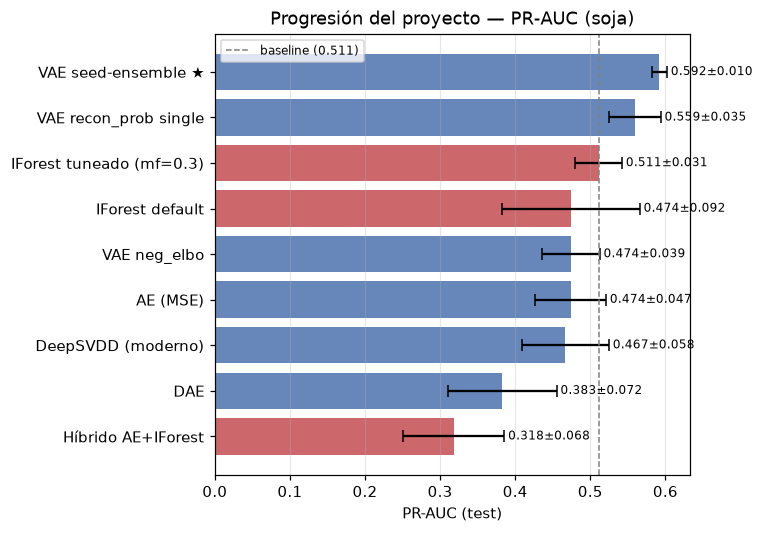

In [7]:
explib.plot_compare(prog, "soja", baseline=0.511, title="Progresión del proyecto — PR-AUC (soja)"); plt.show()

## 6.3 · El modelo final por dentro: `vae_seedens_v1`
VAE `recon_prob` (lat 16, hidden [64,32], β=1) × 10 semillas, scores z-normalizados y
promediados. Métricas completas y punto de operación en ambos cultivos (ver nb. 1 por
qué se re-umbraliza sobre el propio test):

In [8]:
explib.show(explib.run_metrics("vae_seedens_v1", "soja"))

,metrica,valor,std
0,PR-AUC,0.5921,0.0101
1,ROC-AUC,0.7380,0.0050
2,F1,0.4325,0.0027
3,Precision@k,0.5577,0.0128
4,Recall@contam,0.2970,0.0018


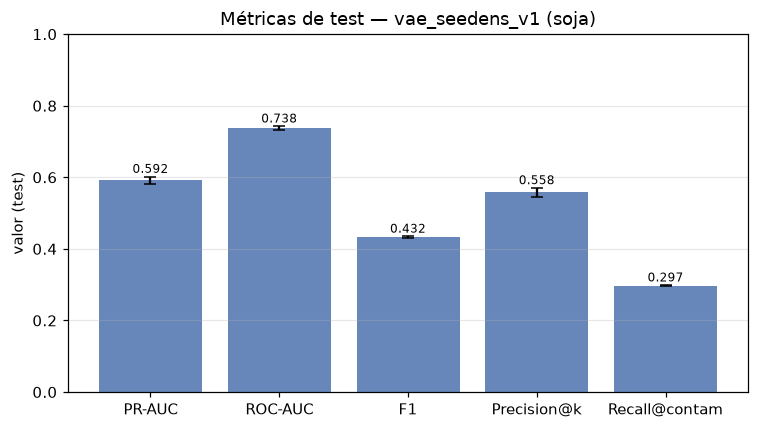

In [9]:
explib.plot_all_metrics("vae_seedens_v1", "soja"); plt.show()

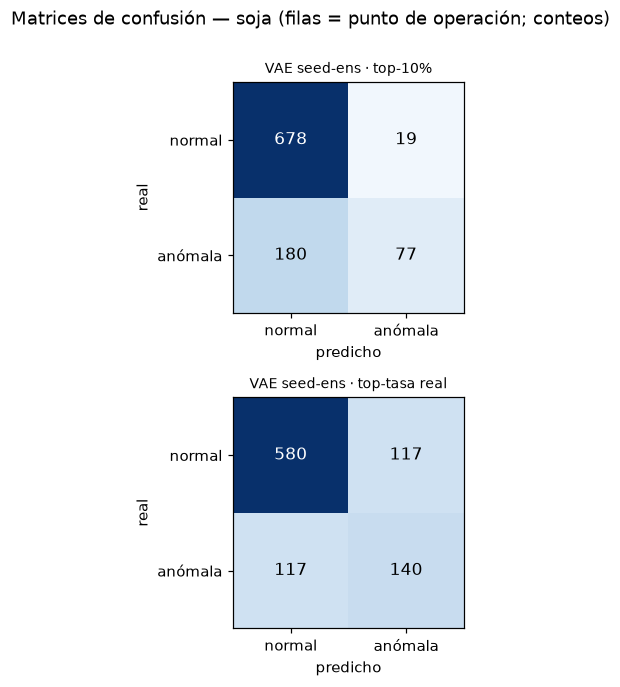

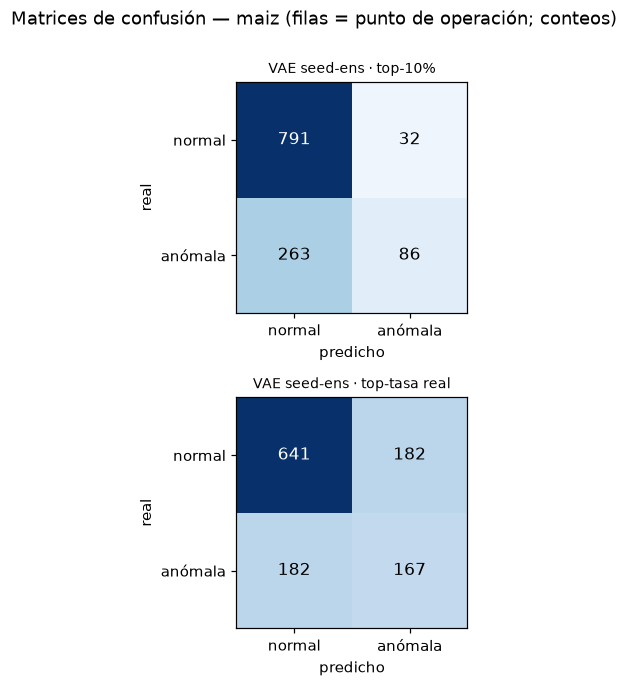

In [10]:
explib.plot_confusion_grid([("vae_seedens_v1", "VAE seed-ens")], "soja"); plt.show()
explib.plot_confusion_grid([("vae_seedens_v1", "VAE seed-ens")], "maiz"); plt.show()

In [11]:
explib.show(explib.confusion_report("vae_seedens_v1", "soja"))

,top-10%,top-tasa real
TP/FP/FN/TN,77/19/180/678,140/117/117/580
Precision,0.802,0.545
Recall,0.3,0.545
Especificidad,0.973,0.832
F1,0.436,0.545
Balanced acc,0.636,0.688


Al **top-10%**, precisión ~0.8: casi todo lo que marca es anomalía real, con recall
acotado por el presupuesto de alertas; al **top-tasa real** se equilibran. Los falsos
positivos restantes son campañas de clima raro con rinde normal — coherente con el
techo del nb. 4.

## 6.4 · Limitaciones
1. **Distribution shift temporal**: scores y tasa base suben de val a test (el clima
   2021–24 se aleja del train; el test incluye la sequía 2022/23). Por eso todo se
   decide por PR-AUC (ranking) y los umbrales se re-calibran por split (nb. 1).
2. **Validación chica** (5–9 anomalías): sus métricas son ruido y no permiten
   seleccionar; las comparaciones se ilustran en test con el *data snooping* declarado
   (nb. 1).
3. **Techo estructural**: la mayoría de las anomalías de rinde no tiene causa climática
   ni vegetacional observable — límite del problema, no del modelo (nbs. 4–5).

## Conclusiones del Componente A
1. **Modelo final: `vae_seedens_v1`** — seed-ensemble ×10 del VAE con score
   `recon_prob` (An & Cho 2015): **soja 0.592 ± 0.010, maíz 0.508 ± 0.005**, el desvío
   más chico del leaderboard. Supera al baseline en media **y en peor caso**, en ambos
   cultivos.
2. Las **dos decisiones de arquitectura** que explican el resultado: el **score
   probabilístico** `recon_prob` sin regularización pesada (nb. 2) y el **ensemble de
   semillas** (nb. 3).
3. Las alternativas quedaron refutadas experimentalmente: tuning de HP del AE, scoring
   max/top-k, híbrido AE+IForest (nb. 2), Student-t, hetero-ensemble (nb. 3), features
   agro/NDVI/ERA5 (nb. 5) y el deep AD moderno a presupuesto parejo (nb. 6).
4. El desempeño está acotado por un **techo estructural** demostrado por tres análisis
   independientes (nb. 4): la mayoría de las anomalías de rinde no deja huella en las
   features disponibles. Mejorar de acá en adelante requiere **otra clase de datos**
   (sanidad, granizo, manejo), no otro modelo.